<a href="https://colab.research.google.com/github/fralfaro/MA_M3/blob/main/evaluaciones/tarea_02_visualizacion_eda_sol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 2: Visualizacion de datos y analisis exploratorio

## Objetivo

Desarrollar un analisis exploratorio visual de ventas e-commerce usando **Matplotlib**. El objetivo es transformar los KPI y tablas de la Tarea 1 en visualizaciones claras que permitan comunicar hallazgos y apoyar decisiones comerciales.

## Contexto

Se utilizara el mismo archivo `evaluaciones/data.csv`. Puede reutilizar el proceso de limpieza de la Tarea 1, dejando el codigo ordenado al inicio del notebook.

## Entrega

Entregar este notebook completo, ejecutado y ordenado. Cada grafico debe estar construido con Matplotlib, tener titulo, ejes claros e interpretacion breve.


## 0. Carga de librerias y datos

Cargue los datos, limpielos y cree las variables necesarias para visualizar ventas, clientes, productos y tiempo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("bmh")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "legend.frameon": True,
    "legend.framealpha": 0.9,
})

ruta = "https://raw.githubusercontent.com/fralfaro/MA_M3/refs/heads/main/evaluaciones/data.csv"  # Si ejecutas desde Colab
df = pd.read_csv(ruta, encoding="latin1")
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [2]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["is_cancelled"] = df["InvoiceNo"].astype(str).str.startswith("C")

df_clean = df.drop_duplicates().copy()
df_clean = df_clean[
    (~df_clean["is_cancelled"]) &
    (df_clean["Quantity"] > 0) &
    (df_clean["UnitPrice"] > 0)
].copy()

df_clean["TotalAmount"] = df_clean["Quantity"] * df_clean["UnitPrice"]
df_clean["Year"] = df_clean["InvoiceDate"].dt.year
df_clean["Month"] = df_clean["InvoiceDate"].dt.month
df_clean["YearMonth"] = df_clean["InvoiceDate"].dt.to_period("M").astype(str)
df_clean["InvoiceDateOnly"] = df_clean["InvoiceDate"].dt.date

df_clean.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancelled,TotalAmount,Year,Month,YearMonth,InvoiceDateOnly
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,15.30,2010,12,2010-12,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,2010,12,2010-12,2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,22.00,2010,12,2010-12,2010-12-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,2010,12,2010-12,2010-12-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,2010,12,2010-12,2010-12-01


## Preguntas

### 1. Evolucion mensual de ventas

Construya un grafico de linea con la venta total por mes.

Responda:

- En que meses se observan mayores ventas?
- Existe algun patron temporal relevante?
- Que recomendacion comercial se podria proponer a partir del grafico?

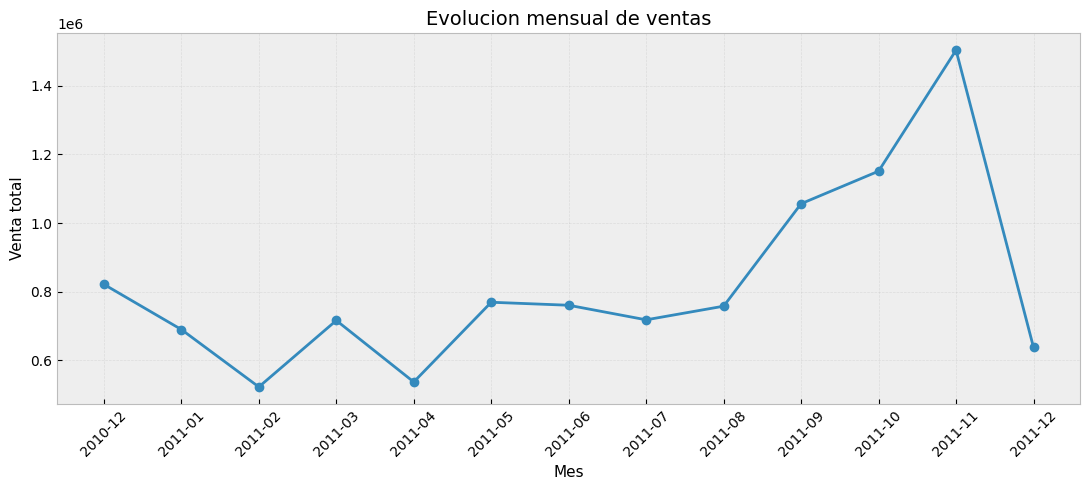

Meses con mayores ventas:


,YearMonth,Venta_total
11,2011-11,1503866.780
10,2011-10,1151263.730
9,2011-09,1056435.192


Interpretacion: las ventas aumentan hacia el cierre de 2011, especialmente en noviembre.
Recomendacion: reforzar inventario, campanas y promociones antes de los meses de mayor demanda.


In [3]:
ventas_mensuales = (
    df_clean
    .groupby("YearMonth", as_index=False)
    .agg(Venta_total=("TotalAmount", "sum"))
    .sort_values("YearMonth")
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ventas_mensuales["YearMonth"], ventas_mensuales["Venta_total"], marker="o", linewidth=2)
ax.set_title("Evolucion mensual de ventas")
ax.set_xlabel("Mes")
ax.set_ylabel("Venta total")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

meses_top = ventas_mensuales.sort_values("Venta_total", ascending=False).head(3)
print("Meses con mayores ventas:")
display(meses_top)
print("Interpretacion: las ventas aumentan hacia el cierre de 2011, especialmente en noviembre.")
print("Recomendacion: reforzar inventario, campanas y promociones antes de los meses de mayor demanda.")


### 2. Ranking de paises por venta

Construya un grafico de barras horizontales con los 10 paises con mayor venta total.

Responda:

- Que pais concentra la mayor venta?
- Conviene incluir o excluir United Kingdom para observar mejor el resto de paises? Justifique.
- Que oportunidad comercial podria existir en otros mercados?

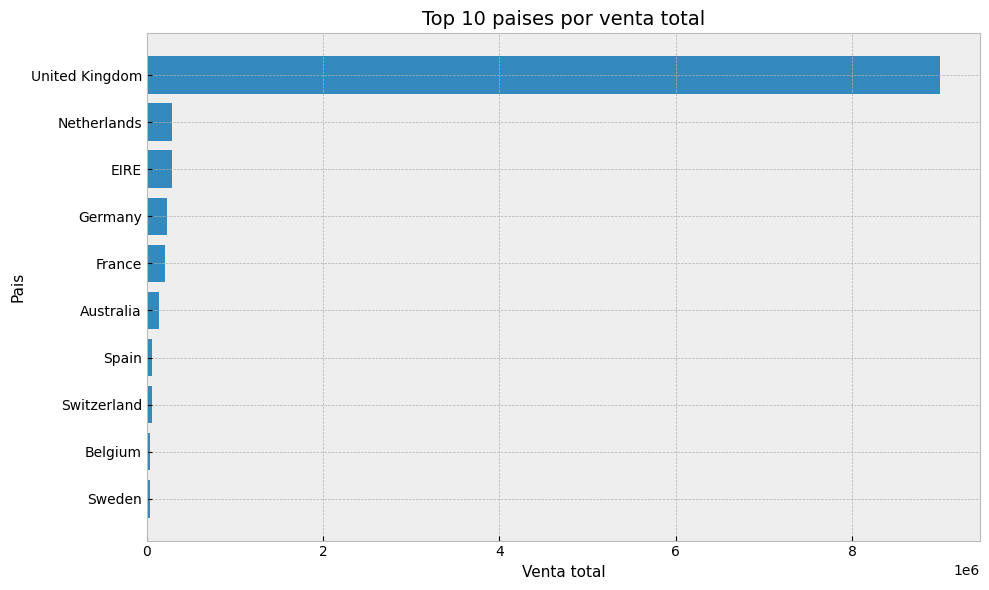

Pais con mayor venta: United Kingdom
Interpretacion: United Kingdom concentra gran parte de la venta y puede ocultar diferencias entre el resto de mercados.
Oportunidad: analizar por separado paises como Netherlands, EIRE, Germany y France para disenar acciones comerciales especificas.


In [4]:
top_paises = (
    df_clean
    .groupby("Country", as_index=False)
    .agg(Venta_total=("TotalAmount", "sum"))
    .sort_values("Venta_total", ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_paises["Country"], top_paises["Venta_total"])
ax.invert_yaxis()
ax.set_title("Top 10 paises por venta total")
ax.set_xlabel("Venta total")
ax.set_ylabel("Pais")
plt.tight_layout()
plt.show()

print("Pais con mayor venta:", top_paises.iloc[0]["Country"])
print("Interpretacion: United Kingdom concentra gran parte de la venta y puede ocultar diferencias entre el resto de mercados.")
print("Oportunidad: analizar por separado paises como Netherlands, EIRE, Germany y France para disenar acciones comerciales especificas.")


### 3. Productos con mayor venta

Construya un grafico de barras con los 10 productos de mayor venta total.

Responda:

- Que productos lideran la venta?
- El ranking parece depender mas de volumen, precio o ambos?
- Que decision de inventario o promocion se podria tomar?

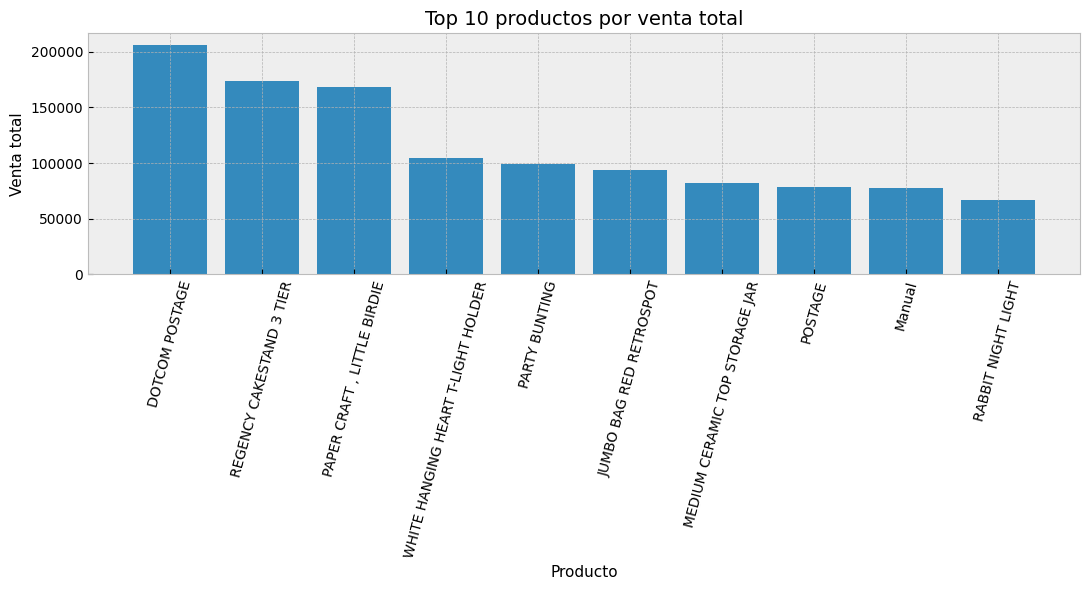

,StockCode,Description,Venta_total,Cantidad_vendida,Precio_promedio,Producto
4150,DOT,DOTCOM POSTAGE,206248.77,706,292.137068,DOTCOM POSTAGE
1340,22423,REGENCY CAKESTAND 3 TIER,174156.54,13851,13.983936,REGENCY CAKESTAND 3 TIER
2668,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,2.080000,"PAPER CRAFT , LITTLE BIRDIE"
3640,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,37580,3.116159,WHITE HANGING HEART T-LIGHT HOLDER
2877,47566,PARTY BUNTING,99445.23,18283,5.797928,PARTY BUNTING
3619,85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,2.486197,JUMBO BAG RED RETROSPOT
2123,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,1.468480,MEDIUM CERAMIC TOP STORAGE JAR
4153,POST,POSTAGE,78101.88,3150,31.076581,POSTAGE
4151,M,Manual,77750.27,6984,234.489652,Manual
2029,23084,RABBIT NIGHT LIGHT,66870.03,30739,2.386401,RABBIT NIGHT LIGHT


Interpretacion: el ranking de venta depende tanto de cantidad vendida como de precio unitario.
Decision sugerida: asegurar stock de los productos lideres y revisar promociones para productos con alta rotacion.


In [5]:
top_productos_venta = (
    df_clean
    .groupby(["StockCode", "Description"], as_index=False)
    .agg(
        Venta_total=("TotalAmount", "sum"),
        Cantidad_vendida=("Quantity", "sum"),
        Precio_promedio=("UnitPrice", "mean")
    )
    .sort_values("Venta_total", ascending=False)
    .head(10)
)

top_productos_venta["Producto"] = top_productos_venta["Description"].str.slice(0, 35)

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(top_productos_venta["Producto"], top_productos_venta["Venta_total"])
ax.set_title("Top 10 productos por venta total")
ax.set_xlabel("Producto")
ax.set_ylabel("Venta total")
ax.tick_params(axis="x", rotation=75)
plt.tight_layout()
plt.show()

display(top_productos_venta)
print("Interpretacion: el ranking de venta depende tanto de cantidad vendida como de precio unitario.")
print("Decision sugerida: asegurar stock de los productos lideres y revisar promociones para productos con alta rotacion.")


### 4. Distribucion del ticket por factura

Calcule el monto total por factura y visualice su distribucion usando histograma o boxplot.

Responda:

- Como se distribuyen los tickets de compra?
- Existen valores extremos?
- Que implicancia tiene esto para interpretar promedios?

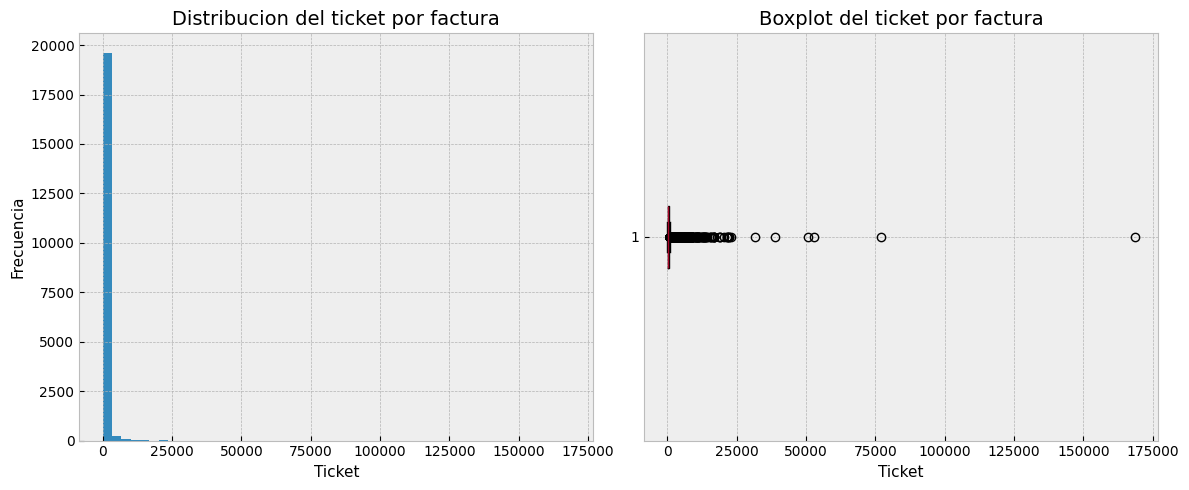

,Ticket
count,19960.000000
mean,533.171884
std,1780.412288
min,0.380000
25%,151.695000
50%,303.300000
75%,493.462500
max,168469.600000


Interpretacion: la distribucion esta sesgada a la derecha, con pocas facturas de monto muy alto.
Implicancia: el promedio puede verse afectado por valores extremos; conviene revisar tambien mediana y percentiles.


In [6]:
ticket_factura = (
    df_clean
    .groupby("InvoiceNo", as_index=False)
    .agg(Ticket=("TotalAmount", "sum"))
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(ticket_factura["Ticket"], bins=50)
axes[0].set_title("Distribucion del ticket por factura")
axes[0].set_xlabel("Ticket")
axes[0].set_ylabel("Frecuencia")

axes[1].boxplot(ticket_factura["Ticket"], vert=False)
axes[1].set_title("Boxplot del ticket por factura")
axes[1].set_xlabel("Ticket")

plt.tight_layout()
plt.show()

display(ticket_factura["Ticket"].describe())
print("Interpretacion: la distribucion esta sesgada a la derecha, con pocas facturas de monto muy alto.")
print("Implicancia: el promedio puede verse afectado por valores extremos; conviene revisar tambien mediana y percentiles.")


### 5. Clientes de mayor valor

Identifique los 10 clientes con mayor venta total y visualicelos con un grafico de barras.

Responda:

- Que tan concentrada esta la venta en los principales clientes?
- Que accion de fidelizacion podria recomendar?
- Que limitacion tiene este analisis si existen `CustomerID` nulos?

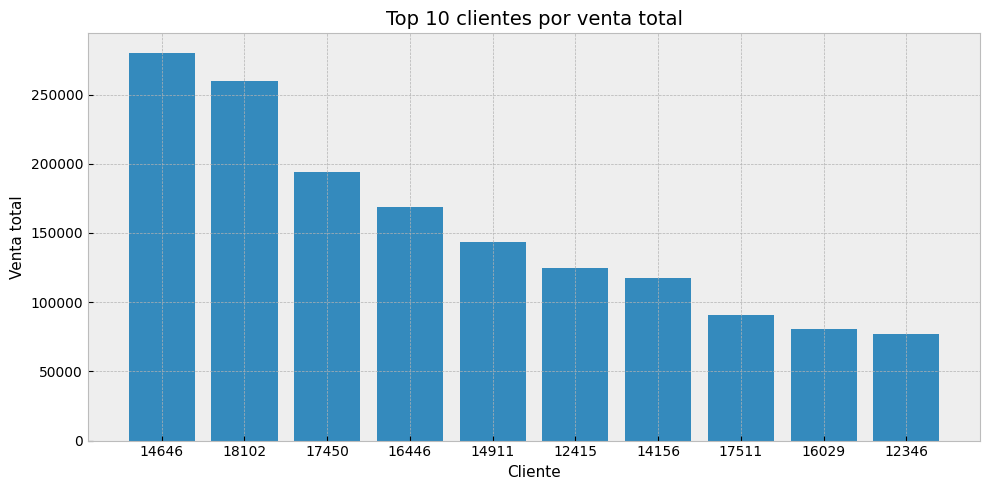

,CustomerID,Venta_total,Facturas
1689,14646,280206.02,73
4201,18102,259657.30,60
3728,17450,194390.79,46
3008,16446,168472.50,2
1879,14911,143711.17,201
55,12415,124914.53,21
1333,14156,117210.08,55
3771,17511,91062.38,31
2702,16029,80850.84,63
0,12346,77183.60,1


Interpretacion: una parte relevante de la venta esta concentrada en clientes de alto valor.
Accion sugerida: crear acciones de fidelizacion, beneficios o seguimiento comercial para estos clientes.
Limitacion: los CustomerID nulos impiden asignar parte de la venta a clientes especificos.


In [7]:
clientes_valor = (
    df_clean
    .dropna(subset=["CustomerID"])
    .groupby("CustomerID", as_index=False)
    .agg(Venta_total=("TotalAmount", "sum"), Facturas=("InvoiceNo", "nunique"))
    .sort_values("Venta_total", ascending=False)
    .head(10)
)

clientes_valor["CustomerID"] = clientes_valor["CustomerID"].astype(int).astype(str)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(clientes_valor["CustomerID"], clientes_valor["Venta_total"])
ax.set_title("Top 10 clientes por venta total")
ax.set_xlabel("Cliente")
ax.set_ylabel("Venta total")
plt.tight_layout()
plt.show()

display(clientes_valor)
print("Interpretacion: una parte relevante de la venta esta concentrada en clientes de alto valor.")
print("Accion sugerida: crear acciones de fidelizacion, beneficios o seguimiento comercial para estos clientes.")
print("Limitacion: los CustomerID nulos impiden asignar parte de la venta a clientes especificos.")


### 6. Relacion entre cantidad, precio y venta

Construya un grafico de dispersion entre `Quantity` y `UnitPrice`, usando `TotalAmount` como referencia adicional si lo considera necesario.

Responda:

- Que relacion observa entre cantidad y precio unitario?
- Existen productos de alto volumen y bajo precio?
- Existen productos de bajo volumen y alto precio?
- Que precauciones debe tomar al graficar valores extremos?

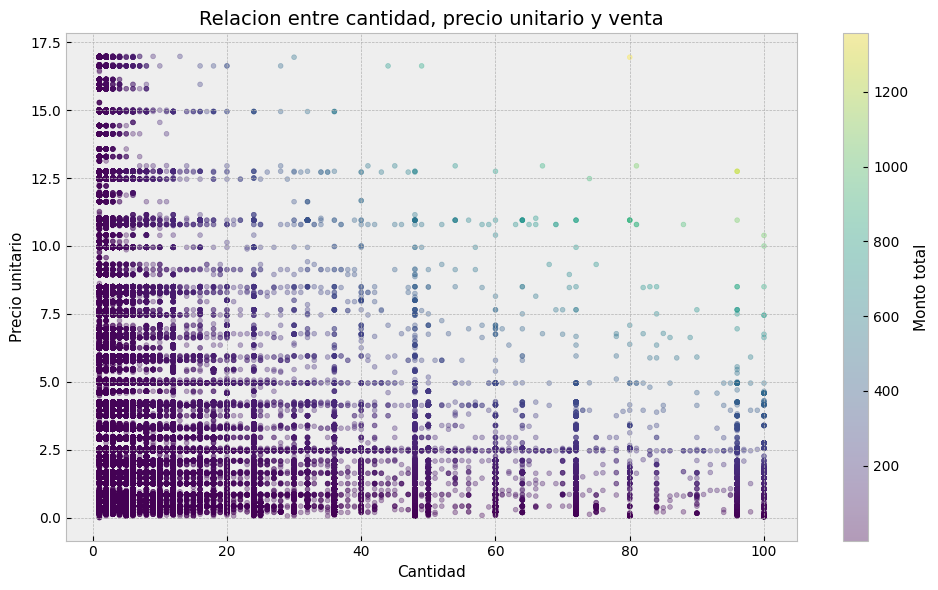

Interpretacion: predominan compras de baja cantidad y bajo precio unitario.
Tambien existen productos de alto volumen y bajo precio, ademas de casos de bajo volumen con precio alto.
Precaucion: se filtraron valores extremos al percentil 99 para que el grafico sea legible.


In [8]:
df_scatter = df_clean[
    (df_clean["Quantity"] <= df_clean["Quantity"].quantile(0.99)) &
    (df_clean["UnitPrice"] <= df_clean["UnitPrice"].quantile(0.99))
].copy()

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    df_scatter["Quantity"],
    df_scatter["UnitPrice"],
    c=df_scatter["TotalAmount"],
    alpha=0.35,
    s=12,
    cmap="viridis"
)
ax.set_title("Relacion entre cantidad, precio unitario y venta")
ax.set_xlabel("Cantidad")
ax.set_ylabel("Precio unitario")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Monto total")
plt.tight_layout()
plt.show()

print("Interpretacion: predominan compras de baja cantidad y bajo precio unitario.")
print("Tambien existen productos de alto volumen y bajo precio, ademas de casos de bajo volumen con precio alto.")
print("Precaucion: se filtraron valores extremos al percentil 99 para que el grafico sea legible.")


### 7. Comparacion de indicadores por pais

Para los principales paises, compare al menos dos indicadores en una visualizacion:

- Venta total.
- Numero de facturas.
- Ticket promedio.
- Clientes unicos.

Puede usar barras agrupadas, subplots o una tabla visual complementada con grafico.

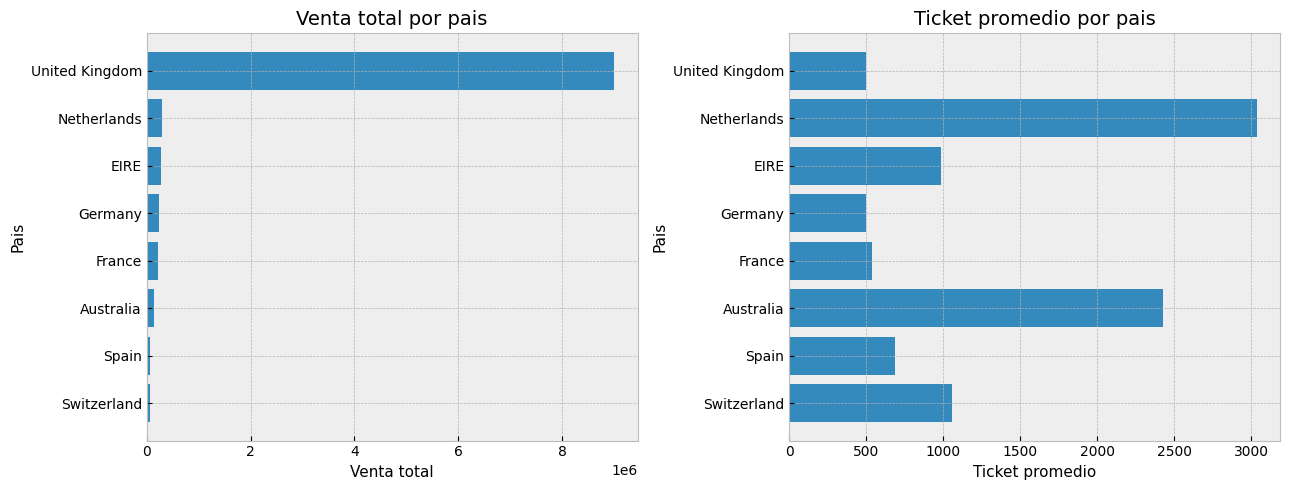

,Country,Venta_total,Facturas,Clientes_unicos,Ticket_promedio
36,United Kingdom,9001744.094,18019,3920,499.569571
24,Netherlands,285446.340,94,9,3036.663191
10,EIRE,283140.520,288,3,983.126806
14,Germany,228678.400,457,94,500.390372
13,France,209625.370,392,87,534.758597
0,Australia,138453.810,57,9,2429.014211
31,Spain,61558.560,90,30,683.984000
33,Switzerland,57067.600,54,21,1056.807407


Interpretacion: el pais con mas venta total no necesariamente tiene el ticket promedio mas alto.
Esto permite separar mercados grandes por volumen de mercados atractivos por valor promedio de compra.


In [9]:
indicadores_pais = (
    df_clean
    .groupby("Country", as_index=False)
    .agg(
        Venta_total=("TotalAmount", "sum"),
        Facturas=("InvoiceNo", "nunique"),
        Clientes_unicos=("CustomerID", "nunique")
    )
)
indicadores_pais["Ticket_promedio"] = indicadores_pais["Venta_total"] / indicadores_pais["Facturas"]
indicadores_pais = indicadores_pais.sort_values("Venta_total", ascending=False).head(8)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(indicadores_pais["Country"], indicadores_pais["Venta_total"])
axes[0].invert_yaxis()
axes[0].set_title("Venta total por pais")
axes[0].set_xlabel("Venta total")
axes[0].set_ylabel("Pais")

axes[1].barh(indicadores_pais["Country"], indicadores_pais["Ticket_promedio"])
axes[1].invert_yaxis()
axes[1].set_title("Ticket promedio por pais")
axes[1].set_xlabel("Ticket promedio")
axes[1].set_ylabel("Pais")

plt.tight_layout()
plt.show()

display(indicadores_pais)
print("Interpretacion: el pais con mas venta total no necesariamente tiene el ticket promedio mas alto.")
print("Esto permite separar mercados grandes por volumen de mercados atractivos por valor promedio de compra.")


In [10]:
storytelling = """
Las ventas muestran una tendencia de crecimiento hacia el cierre de 2011, con noviembre como mes destacado.
United Kingdom concentra la mayor parte de la venta total, por lo que conviene analizarlo separado del resto de paises.
Otros mercados como Netherlands, EIRE, Germany y France aparecen como oportunidades relevantes para expansion o campanas focalizadas.
El ranking de productos indica que la venta depende de una combinacion de volumen y precio, no solo de unidades vendidas.
La distribucion del ticket por factura esta sesgada por valores extremos, por lo que el promedio debe interpretarse con cuidado.
Los clientes de mayor valor concentran una parte importante de los ingresos y justifican acciones de fidelizacion.
Una limitacion importante es la presencia de CustomerID nulos, que reduce la precision del analisis de clientes.
Tambien existen valores extremos en cantidad y precio, por lo que los graficos deben controlarse con filtros o percentiles.
Se recomienda reforzar inventario y marketing antes de los meses de mayor demanda.
Ademas, se sugiere crear campanas diferenciadas para clientes de alto valor y mercados internacionales con buen ticket promedio.
"""

print(storytelling)



Las ventas muestran una tendencia de crecimiento hacia el cierre de 2011, con noviembre como mes destacado.
United Kingdom concentra la mayor parte de la venta total, por lo que conviene analizarlo separado del resto de paises.
Otros mercados como Netherlands, EIRE, Germany y France aparecen como oportunidades relevantes para expansion o campanas focalizadas.
El ranking de productos indica que la venta depende de una combinacion de volumen y precio, no solo de unidades vendidas.
La distribucion del ticket por factura esta sesgada por valores extremos, por lo que el promedio debe interpretarse con cuidado.
Los clientes de mayor valor concentran una parte importante de los ingresos y justifican acciones de fidelizacion.
Una limitacion importante es la presencia de CustomerID nulos, que reduce la precision del analisis de clientes.
Tambien existen valores extremos en cantidad y precio, por lo que los graficos deben controlarse con filtros o percentiles.
Se recomienda reforzar inventario 

## Rubrica sugerida

| Criterio | Ponderacion |
|---|---:|
| Limpieza y preparacion del dataset | 15% |
| Calidad tecnica de los graficos | 30% |
| Variedad y pertinencia de visualizaciones | 20% |
| Interpretacion orientada a negocio | 25% |
| Orden, reproducibilidad y presentacion | 10% |